# DNN- Regression

## 1. 데이터셋 불러와서 학습준비

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


In [3]:
df = pd.read_csv('data/fetch_california_housing.csv')

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
# X, y 분리

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

print(X.shape, y.shape)

(20640, 8) (20640,)


In [7]:
# 학습데이터와 테스트 데이터 분리(학습 80% , 테스트 20%, random_state= 42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42
)

print(len(X_train),len(X_test),len(y_train),len(y_test))

16512 4128 16512 4128


In [8]:
# StandardScaler 정규화  (학습데이터는 학습/ 변환, 테스트 데이터는 변환)

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

ndarray 형태인 X_train_scaled를 DataFrame 형식으로 재구성

In [13]:
# 스케일링 된 데이터 DataFrame 형태로 유지
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns= X_train.columns,   # 기존 컬럼명
    index= X_train.index        # 기존 인덱스
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns= X_test.columns,
    index= X_test.index
)


X_train_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551
...,...,...,...,...,...,...,...,...
11284,1.307215,0.507194,0.290620,-0.393391,-0.675847,-0.005588,-0.872016,0.808883
11964,-0.436266,0.348490,0.600411,0.398898,0.287195,0.069722,-0.759688,1.073144
5390,-0.496973,0.586545,-0.606759,-0.039216,0.289833,0.020306,-0.755007,0.599469
860,0.965450,-1.079841,0.402175,-0.066265,0.308303,0.007076,0.906510,-1.185540


2. PyTorch 를 이용한 모델 학습

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
X_train_tensor = torch.from_numpy(X_train_scaled.to_numpy()).float()            # train데이터 FloatTensor형태로 변환
X_test_tensor = torch.from_numpy(X_test_scaled.to_numpy()).float()


y_train_tensor = torch.from_numpy(y_train.values).float().reshape(-1, 1)        # (샘플수, 1) 형태로 변환시켜 학습에 사용
y_test_tensor = torch.from_numpy(y_test.values).float().reshape(-1, 1)

print(X_train_tensor.size(), X_test_tensor.size(), y_train_tensor.size(), y_test_tensor.size())

torch.Size([16512, 8]) torch.Size([4128, 8]) torch.Size([16512, 1]) torch.Size([4128, 1])


In [17]:
# 하이퍼파라미터 설정
n_epochs = 5000         # 반복횟수
learning_rate = 1e-3    # 학습률
print_interval = 500    # 로그 출력 간격

3. 모델 구축
- nn.Sequential 사용

- 입력을 받아 64개 노드 은닉층
- 64개 노드 -> 64개 은닉층
- 64개 노드 -> 32개 은닉층
- 32개 노드 -> 출력층
- 활성화 함수는 ReLU()

In [ ]:
# 모델 구축
model = nn.Sequential(
    # 특성의 갯수(tensor 의 열)
    nn.Linear(X_train_tensor.size(-1), 64),        # 입력층 -> 은닉층 64개 노드로 보냄
    nn.ReLU(),                          # 비선형성 추가
    
    nn.Linear(64, 64),                  # 은닉층 -> 은닉층
    nn.ReLU(),
    
    nn.Linear(64, 32),
    nn.ReLU(),
    
    nn.Linear(32, y_train_tensor.size(-1))  # 회귀는 출력 차원 1
)

model

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)

In [20]:
# Adam 최적화 함수 : 모멘텀 + RMSProp 을 결합한 최적화 알고리즘, 빠르고 안정적

optimizer = optim.Adam(
    model.parameters(),     # 학습 대상 : 가중치, 편향 파라미터
    lr = learning_rate      # 학습률
)

In [21]:
torch.cuda.is_available()

False

In [22]:
# CPU / GPU 디바이스 설정

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # GPU 사용 가능하면 cuda 사용, 아니면 CPU
model = model.to(device)    # 모델 이동



In [33]:
# CPU/GPU 로 데이터 이동
X_train = X_train_tensor.to(device)
X_test = X_test_tensor.to(device)
y_train = y_train_tensor.to(device)
y_test = y_test_tensor.to(device)

In [34]:
# 학습 루프
for epoch in range(n_epochs):
    model.train()                       # 학습 모드(dropout, batchnorm 활성화 : 과적합 방지기법)
    
    y_hat = model(X_train)              # 순전파 : 모델 예측값 계산
    loss = F.mse_loss(y_hat, y_train)   # 평균 제곱오차(MSE) 손실 계산
    
    optimizer.zero_grad()   # 기존 루프의 기울기 초기화
    loss.backward()         # 역전파 : 손실을 기준으로 기울기 재계산
    
    optimizer.step()        # 파라미터 업데이트
    
    
    # 500번 마다 학습손실 출력
    if (epoch + 1) % print_interval ==0:
        print(f'Epoch {epoch + 1}의 Train Loss : {loss.item():.4e}')
        
# 테스트
model.eval()            # 평가 모드(dropout, batchnorm 비활성화)
with torch.no_grad():   # 기울기 계산 비활성화
    y_pred_test = model(X_test)     # 테스트 데이터 예측
    test_loss = F.mse_loss(y_pred_test, y_test)     # 테스트 손실 계산
print(f'Test MSE : {test_loss.item():.4e}')         # 테스트 MSE 출력

Epoch 500의 Train Loss : 1.4992e-01
Epoch 1000의 Train Loss : 1.4756e-01
Epoch 1500의 Train Loss : 1.4859e-01
Epoch 2000의 Train Loss : 1.4518e-01
Epoch 2500의 Train Loss : 1.4326e-01
Epoch 3000의 Train Loss : 1.4436e-01
Epoch 3500의 Train Loss : 1.4312e-01
Epoch 4000의 Train Loss : 1.4096e-01
Epoch 4500의 Train Loss : 1.4135e-01
Epoch 5000의 Train Loss : 1.4070e-01
Test MSE : 3.1215e-01


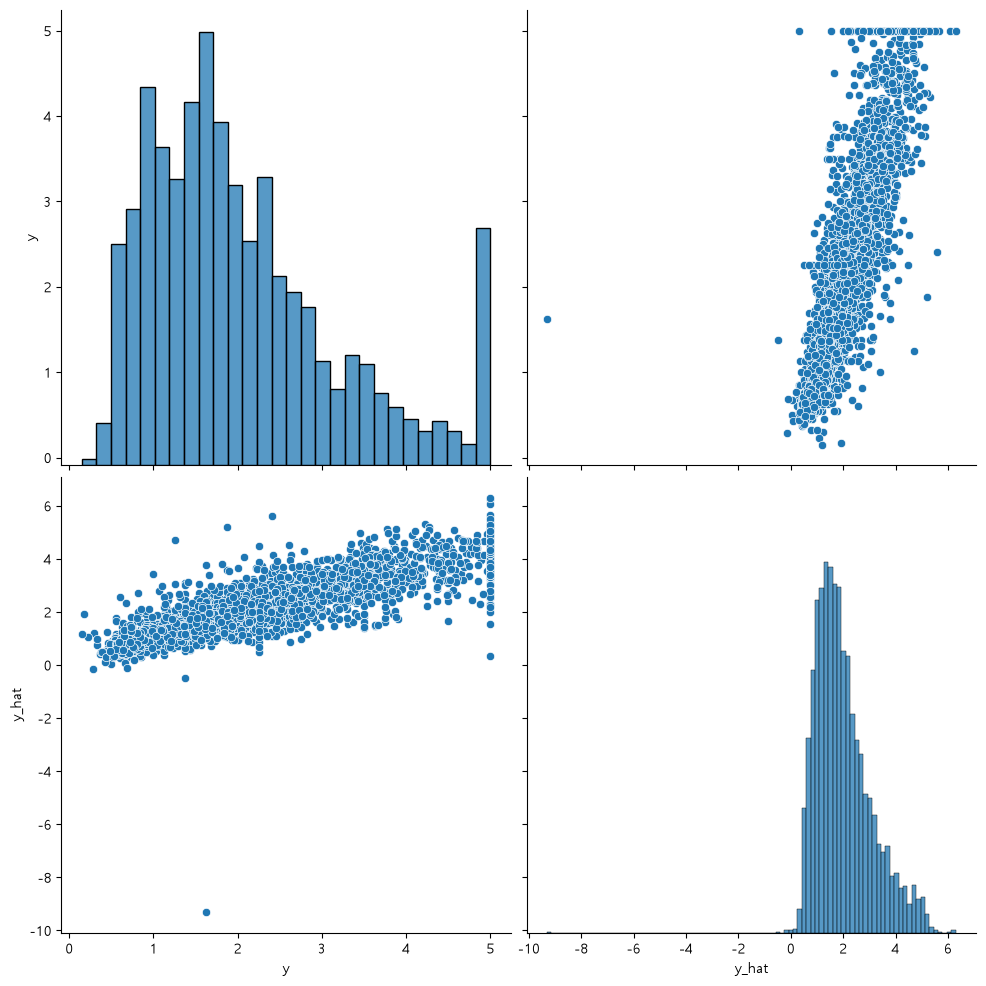

In [35]:
#GPU에서 학습한 모델, 데이터를 다시 cpu로 가져와서 시각화
model.eval()
with torch.no_grad():       # 추론시
    y_pred = model(X_test).cpu().numpy().reshape(-1) # 예측값을 CPU로 이동 -> numpy_> 배열형태로
    y_true = y_test.cpu().numpy().reshape(-1)        # 정답값도 CPU -> Numpy -> 1차원 배열로 변환

df_result = pd.DataFrame({
    'y' :y_true,
    'y_hat' : y_pred
})

sns.pairplot(df_result, height=5)
plt.show()